# INTRODUCTION TO CLIP:
CLIP stands for **Contrastive Language-Image Pretraining**. CLIP connects images and text in a **shared embedding space**. This allows model to understand images using natuaral language descriptions instead of only fixed labels.

Two neural networks are trained together:
1. **Image Encoder**:
  - Converts an image into a numerical vector often based on the **CNNs or Vision Transformers**.
  - Returns 512 dimensions.
2. **Text Encoder**:
  - Converts a sentence or phrase into a vector usually based on a **Transformer Language Model**.
  - Returns 512 dimensions.
Both outputs are vectors in the same dimensional space.

## CLIP WORKFLOW:
1. **Step 1:** Input Pair.
  - It takes an image and its corresponding caption as input.
2. **Step 2:** Encoding.
  - Image goes through the **Image Encoder**.
  - Text goes through the **Text Encoder**.
3. **Step 3:** Similarity Measurements.
  - Model calculates the cosine similarity between the image and text vectors.
4. **Contrastive Learning:**
  - CLIP trains using **contrastive loss**.

## UNDERSTANDING THE SHOTS:
1. **Zero Shots:** The model performs a task without seeing any examples in the prompt. Use case: when the model already understands the task from training.
```
Translate this sentence to French:
"I love learning AI."
```
2. **One-Shot:** The model is given one example before the actual question.
```
English: Hello
French: Bonjour

English: Thank you
French:
```
3. **Few-Short:** The model receives several examples before solving the task.
```
English: Hello
French: Bonjour

English: Good morning
French: Bonjour

English: Thank you
French:
```

# IMPLEMENTATION OF CLIP FROM SCRATCH:
Things we need:
1. Load Libraries
2. Load Dataset
3. Implement Text Encoder
  - Attention Module is needed.
  - MultiHeadAttention Module is needed.
  - Transformer Encoder is needed.
  - Positional Embedding is needed.
  - Tokenizer is needed.
4. Implement Image Encoder.
  - Positional Embedding is needed.
  - Transformer Encoder is needed.
  - MultiHeadAttention Module is needed.
  - Attention Module is needed.
5. Implement Cosine Similarity Function.
6. Implement Loss Functions.
7. Train and Evaluate.

## Import Libraries

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

## IMPLEMENTING COMMONG MODULES
(Attention, MultiHeadAttention, Transformer Encoder, Positional Embedding)

### Positional Embedding

Transformers do not have recurrence or convolution, they cannot understand the order of tokens in a sequence. Positional encoding adds position information to token embeddings.
`"I love AI"` and `"AI love I"` would look the same without position information. So, we add positional embeddings to token embeddings:

`Final Embedding = Token Embedding + Positional Encoding`

In [29]:
class PositionalEmbedding(nn.Module):
  """
  Module that generates positional encoding, it helps the model to know
  the relative position of each words.
  width -> Embedding Dimension (512).
  max_seq_length -> Maximum Sequence Length.
  """
  def __init__(self, width, max_seq_length):
    super().__init__()

    # Create Encoding Matrix.
    pe = torch.zeros(max_seq_length, width)

    for pos in range(max_seq_length):
      for i in range(width):
        if i%2 == 0:
          pe[pos][i] = np.sin(pos/(10000 ** (i/width)))
        else:
          pe[pos][i] = np.cos(pos/(10000 ** ((i-1)/width)))

    # Save the embeddings.
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    x = x+self.pe

    return x

### Attention Head

A single attention head learns how each word should focus on other words in the sequence.
- `width` → embedding dimension of the input (like 512)
- `head_size` → dimension for this attention head (like 64)
There are 3 Linear Layers:
  - Query (Q): What this word is looking for,
  - Key (K): What this word offers,
  - Value (V): Information Carried bt the word.

-  This `K.transpose(-2,-1)` swaps the last 2 dimensions for matrix multiplication.

- Flowchart of Attention Head
```
Input embeddings
        │
        ▼
   Linear layers
   Q, K, V
        │
        ▼
Q × K^T  → similarity scores
        │
        ▼
Scaling (÷ √d)
        │
        ▼
Mask (optional)
        │
        ▼
Softmax → attention weights
        │
        ▼
Weights × V
        │
        ▼
Output contextual vectors
```
- Example: "The cat sat on the mat"
```
| Word | Attention |
| ---- | --------- |
| The  | 5%        |
| cat  | 45%       |
| sat  | 20%       |
| on   | 15%       |
| mat  | 15%       |
```
So the word "sat" learns context from "cat".
  

In [30]:
class AttentionHead(nn.Module):
  def __init__(self, width, head_size):
    super().__init__()
    self.head_size = head_size

    self.query = nn.Linear(width, head_size)
    self.key = nn.Linear(width, head_size)
    self.value = nn.Linear(width, head_size)

  def forward(self, x, mask=None):
    # Getting Queries, Keys, and Values
    Q = self.query(x)
    K = self.key(x)
    V = self.value(x)

    # The input x is: (batch_size, seq_len, width)
    # Dot product of queries and keys.
    attention = Q @ K.transpose(-2, -1) # (-2, -1) refers to last two dimension of a tensor.

    # De-scaling the head_size, otherwise the dot products become too large,
    # causing softmax saturation.
    attention = attention / (self.head_size ** 0.5)

    # Applying Attention Mask
    # Masking is used in decoder models to prevent looking at future tokens,
    # After softmax they become 0 probability.
    if mask is not None:
      attention = attention.masked_fill(mask==0, float("-inf"))

    # Softmax converts scores into probabilities.
    attention = torch.softmax(attention, dim=-1)

    # Weighted sum of values,
    # Now we combine the value vectors using attention weights,
    # This produces the final contextual representation.
    attention = attention @ V

    return attention


### Multi-Head Attention
The difference is mainly about how many attention mechanisms are used in parallel.

- `AttentionHead` → one attention calculation.
- `MultiHeadAttention` → many attention heads working together.

Multi-head attention runs multiple AttentionHeads in parallel. Instead of learning one relationship, the model learns many different relationships.

Each head can learn different linguistic relationship. For example:
```
| Head   | Focus                   |
| ------ | ----------------------- |
| Head 1 | subject–verb relation   |
| Head 2 | positional relationship |
| Head 3 | noun relationships      |
| Head 4 | long-range dependencies |
```

- Formula: `embedding_space = head_size * heads`

In [31]:
class MultiHeadAttention(nn.Module):
  def __init__(self, width, n_heads):
    super().__init__()

    # Head size calculation
    # Each head gets a portion of embeddings.
    # Every head gets a portion of the embedding dimension.
    self.head_size = width // n_heads # So each head can process 4 features.
    # After combining all heads, we apply a linear layer to mix the informations.
    self.W_o = nn.Linear(width, width)
    # Create Multiple attention heads.
    self.heads = nn.ModuleList([AttentionHead(width, self.head_size) for _ in range(n_heads)])

  def forward(self, x, mask=None): # Here, x is input (batch_size, seq_length, width)
    # Each head process the input, and each attention head creates:
    # Query, Key, Value -> Computes attention -> produces output.
    # Then concatenate the output. `dim=-1` means last dimension (features)
    out = torch.cat([head(x, mask=mask) for head in self.heads], dim = -1)
    # Each head returns (batch, seq_len, head_size). Each head learns different relationships.
    out = self.W_o(out) # We apply linear projection

    return out # Returns (batch, seq_lenth, width)

### Transformer Encoder
A transformer is designed to process sequential data in parallel, rather than step-by-step, using a mechanism called `self-attention`. Transformer has two main parts:
  1. Multi-Head Self Attention
  2. Feed Forward Network (MLP)
These parts use Layer Normalization and Residual Connections.

Parameters:
  - `width`: embedding dimension.
  - `n_heads`: number of attention heads.
  - `r_mlp`: expansion ratio for the ffl.

**Gradient Vanishing:**
In a neural network, we multiply numbers (gradients) together during training.
If we have a deep network with 10 layers and each layer has a gradient of 0.1:
0.1 x 0.1 x 0.1 x 0.1 = 0.00001
The weight update for the first layer is now so small that the computer might even round it down to zero. The layer stops learning completely.

  - `Mitigations`:
  ```
  - Use ReLU Activation.
  - Use Residual/Skip Connections.
  - Batch Normalization.
  - Weigth Initialization (He Initialization, Xavier Initialization)
  ```

# Workflow:
```
Input
 ↓
Normalize
 ↓
Self-Attention
 ↓
Add Residual
 ↓
Normalize
 ↓
Feed Forward Network
 ↓
Add Residual
 ↓
Output
```

In [32]:
class TransformerEncoder(nn.Module):
  def __init__(self, width, n_heads, r_mlp=4):
    super().__init__()
    self.width = width
    self.n_heads = n_heads

    # Sub-layer 1: Normalization
    self.ln1 = nn.LayerNorm(width)

    # Multi-Head Attention
    self.mha = MultiHeadAttention(width, n_heads)

    # Sub-Layer 2: Normalization
    self.ln2 = nn.LayerNorm(width)

    # Multilayer Perception
    # This is a position-wise feed-forward network.
    self.mlp = nn.Sequential(
        nn.Linear(self.width, self.width*r_mlp),
        nn.GELU(),
        nn.Linear(self.width*r_mlp, self.width)
    )

  def forward(self, x, mask=None):
    # First Attention Residual Block
    x = x + self.mha(self.ln1(x), mask=mask)
    # Second Residual Block (MLP)
    x = x + self.mlp(self.ln2(x))

    return x # Output: (batch, seq_len, width)

## TEXT ENCODER
This defines a PyTorch neural network module that encodes text using:
  1. Token embeddings
  2. Positional embeddings
  3. Transformer encoder layers
  4. A projection layer to the final embedding space

Inputs:
```
| Parameter        | Meaning                              |
| ---------------- | ------------------------------------ |
| vocab_size     | number of words/tokens in vocabulary |
| width          | embedding dimension                  |
| max_seq_length | maximum sentence length              |
| n_heads        | number of attention heads            |
| n_layers       | number of transformer layers         |
| emb_dim        | final embedding dimension            |
```


In [33]:
def tokenizer(text, encode=True, mask=None, max_seq_length=32):
  if encode:
    out = chr(2)+text+chr(3) # Adding SOT and EOT tokens
    out = out+"".join([chr(0) for _ in range(max_seq_length-len(out))]) # Adding Padding
    out = torch.IntTensor(list(out.encode("utf-8"))) # Encoding text.
    mask = torch.ones(len(out.nonzero()))
    mask = torch.cat((mask, torch.zeros(max_seq_length-len(mask)))).type(torch.IntTensor)
  else:
    out = [chr(x) for x in text[1:len(mask.nonzero()) - 1]]
    out = "".join(out)
    mask = None

  return out, mask

In [34]:
class TextEncoder(nn.Module):
  def __init__(self, vocab_size, width, max_seq_length, n_heads, n_layers, emb_dim):
    super().__init__()

    self.max_seq_length = max_seq_length
    # This converts token IDs → vectors.
    self.encoder_embedding = nn.Embedding(vocab_size, width) # Gives output (batch, seq_len, width)
    # Transformers do not understand word order, so positional embeddings add position information.
    self.positional_embedding = PositionalEmbedding(width, max_seq_length)
    # This creates multiple transformer encoder layers.
    # Each layer consists of: MultiHead Attention, Feed Forward Net, Layer Norm, and Residual Connections.
    self.encoder = nn.ModuleList([TransformerEncoder(width, n_heads) for _ in range(n_layers)])
    # This creates a learnable projection matrix, for multimodal learning.
    self.projection = nn.Parameter(torch.randn(width, emb_dim))

  def forward(self, text, mask=None):
    # Text Embedding
    x = self.encoder_embedding(text)

    # Positional Embedding
    x = self.positional_embedding(x)

    # Transformer Encoder
    for encoder_layer in self.encoder:
      x = encoder_layer(x, mask=mask)

    # Extract End-Of-Text Token Feature.
    # The sentence ending is taken from the EOT token.
    x = x[torch.arange(text.shape[0]), torch.sub(torch.sum(mask[:, 0], dim=1), 1)] # Output: (batch, width)

    if self.projection is not None:
      x = x @ self.projection # Mapping Text vectors to a new embedding space.

    x = x / torch.norm(x, dim=-1, keepdim=True)

    return x


## IMAGE ENCODER

It converts an image into a vector embedding that can later be compared with a text embedding in a shared multimodal space.
```
| Parameter    | Meaning                         |
| ------------ | ------------------------------- |
| width      | hidden dimension of transformer |
| img_size   | image size (H, W)               |
| patch_size | size of each image patch        |
| n_channels | number of channels (3 for RGB)  |
| n_layers   | number of transformer layers    |
| n_heads    | attention heads                 |
| emb_dim    | final embedding dimension       |


In [35]:
class ImageEncoder(nn.Module):
  def __init__(self, width, img_size, patch_size, n_channels, n_layers, n_heads, emb_dim):
    super().__init__()

    # Validity Checks (Image to Patch, and AttentionHead Compatibility)
    assert img_size[0] % patch_size[0] == 0 and img_size[1] % patch_size[1] == 0, "img_size dimension must be divisible by patch_size dimensions"
    assert width % n_heads == 0, "Width must be divisible bt n_heads"

    # Number of patches
    self.n_patches = (img_size[0]*img_size[1]) // (patch_size[0]*patch_size[1])

    # Add max sequence length
    self.max_seq_length = self.n_patches+1 # we add a class token (CLS) that's why +1.

    # Convert image patches into vectors using Conv2D.
    self.linear_project = nn.Conv2d(n_channels, width, kernel_size=patch_size, stride=patch_size)

    # Add a learnable token at the start of the sequence.
    # The CLS token becomes a vector that contains information from all tokens,
    # but only after passing through the Transformer layers, not at initialization.
    self.cls_token = nn.Parameter(torch.randn(1, 1, width))

    # Transformers do not know order, so we add position information.
    self.positional_embedding = PositionalEmbedding(width, self.max_seq_length)

    # Create multiple transformer layers.
    self.encoder = nn.ModuleList([TransformerEncoder(width, n_heads) for _ in range(n_layers)])

    # Projection to Shared Embedding Space. (Text and Image share the same embedding space.)
    self.projection = nn.Parameter(torch.randn(width, emb_dim))

  def forward(self, x):
    # Patch Embedding.
    x = self.linear_project(x)
    x = x.flatten(2).transpose(1, 2)

    # Add CLS token.
    x = torch.cat((self.cls_token.expand(x.size()[0], -1, -1), x),  dim=1)
    x = self.positional_embedding(x)

    # Pass the image to Transformer Layers.
    for encoder_layer in self.encoder:
      x = encoder_layer(x)

    # Take the CLS token.
    x = x[:, 0, :]

    # Joint Multimodal Embedding for Image.
    if self.projection is not None:
      x = x @ self.projection

    x = x / torch.norm(x, dim=-1, keepdim=True)

    return x

## CLIP MODEL

![Image](/content/drive/MyDrive/ML%20&%20DL/CLIP/CLIP.png)

CLIP learns a shared embedding space for images and text, so the correct image–text pairs are close together while incorrect pairs are far apart.

**Image Encoder Parameters:**
```
vit_width	- hidden dimension of Vision Transformer
img_size	- input image size
patch_size	- size of each image patch
n_channels	- image channels (3 for RGB)
vit_layers	- number of transformer layers
vit_heads	- number of attention heads
```

**Text Encoder Parameters:**
```
vocab_size	    - tokenizer vocabulary
text_width	    - hidden dimension
max_seq_length	- max text length
text_heads	    - attention heads
text_layers	    - transformer layers
```

**Shared Embedding:**
```
emb_dim - dimension of joint embedding space
```

In [36]:
class CLIP(nn.Module):
  def __init__(self, emb_dim, vit_width, img_size, patch_size, n_channels, vit_layers,
               vit_heads, vocab_size, text_width, max_seq_length, text_heads, text_layers):
    super().__init__()

    self.image_encoder = ImageEncoder(vit_width, img_size, patch_size, n_channels, vit_layers, vit_heads, emb_dim)

    self.text_encoder = TextEncoder(vocab_size, text_width, max_seq_length, text_heads, text_layers, emb_dim)

    # Sharpens the similarity distribution during training.
    self.temperature = nn.Parameter(torch.ones([]) * np.log(1/0.07))

    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  def forward(self, image, text, mask=None):
    I_e = self.image_encoder(image)
    T_e = self.text_encoder(text, mask=mask)

    # Scaled pairwise cosine similarities.
    logits = (I_e @ T_e.transpose(-2,-1)) * torch.exp(self.temperature)

    # Symmetric loss function.
    labels = torch.arange(logits.shape[0]).to(self.device)

    loss_i = nn.functional.cross_entropy(logits.transpose(-2, -1), labels) # Text Given Image
    loss_t = nn.functional.cross_entropy(logits, labels) # Image Given Text

    loss = (loss_i + loss_t)/2 # Average of both Image and Text loss.

    return loss

## IMPORT DATASET

In [37]:
class FashionMNIST(Dataset):
  def __init__(self, train=True):
    self.dataset = load_dataset("fashion_mnist")

    self.transform = T.ToTensor()

    if train:
      self.split = "train"
    else:
      self.split = "test"

    self.captions = {0: "An image of a t-shirt/top",
                        1: "An image of trousers",
                        2: "An image of a pullover",
                        3: "An image of a dress",
                        4: "An image of a coat",
                        5: "An image of a sandal",
                        6: "An image of a shirt",
                        7: "An image of a sneaker",
                        8: "An image of a bag",
                        9: "An image of an ankle boot"}

  def __len__(self):
    return self.dataset.num_rows[self.split]

  def __getitem__(self, i):
    img = self.dataset[self.split][i]["image"]
    img = self.transform(img)

    cap, mask = tokenizer(self.captions[self.dataset[self.split][i]["label"]])

    mask = mask.repeat(len(mask), 1)

    return {"image": img, "caption": cap, "mask": mask}

## TRAINING MODEL AND PARAMETER SETTING

In [38]:
emb_dim = 32
vit_width = 9
img_size = (28, 28)
patch_size =(14, 14)
n_channels = 1
vit_layers = 3
vit_heads = 3
vocab_size = 256
text_width = 32
max_seq_length = 32
text_heads = 8
text_layers = 4
lr = 1e-3
epochs = 50
batch_size = 128

In [39]:
train_set = FashionMNIST(train=True)
test_set = FashionMNIST(train=False)

train_loader = DataLoader(train_set, shuffle = True, batch_size = batch_size)
test_loader = DataLoader(test_set, shuffle = True, batch_size = batch_size)

Using Device:  cuda (Tesla T4)
Epoch [1/50], Batch Loss: 2.717, Average Loss: 0.006
Model Saved
Epoch [2/50], Batch Loss: 2.993, Average Loss: 0.006
Epoch [3/50], Batch Loss: 2.887, Average Loss: 0.006
Epoch [4/50], Batch Loss: 2.871, Average Loss: 0.006
Epoch [5/50], Batch Loss: 2.695, Average Loss: 0.006
Model Saved
Epoch [6/50], Batch Loss: 2.746, Average Loss: 0.006
Epoch [7/50], Batch Loss: 2.588, Average Loss: 0.006
Model Saved
Epoch [8/50], Batch Loss: 2.699, Average Loss: 0.006
Epoch [9/50], Batch Loss: 2.856, Average Loss: 0.006
Epoch [10/50], Batch Loss: 2.759, Average Loss: 0.006
Epoch [11/50], Batch Loss: 2.686, Average Loss: 0.006
Epoch [12/50], Batch Loss: 2.679, Average Loss: 0.006
Epoch [13/50], Batch Loss: 2.798, Average Loss: 0.006
Epoch [14/50], Batch Loss: 2.721, Average Loss: 0.006
Epoch [15/50], Batch Loss: 2.783, Average Loss: 0.006
Epoch [16/50], Batch Loss: 2.646, Average Loss: 0.006
Epoch [17/50], Batch Loss: 2.612, Average Loss: 0.006
Epoch [18/50], Batch Los

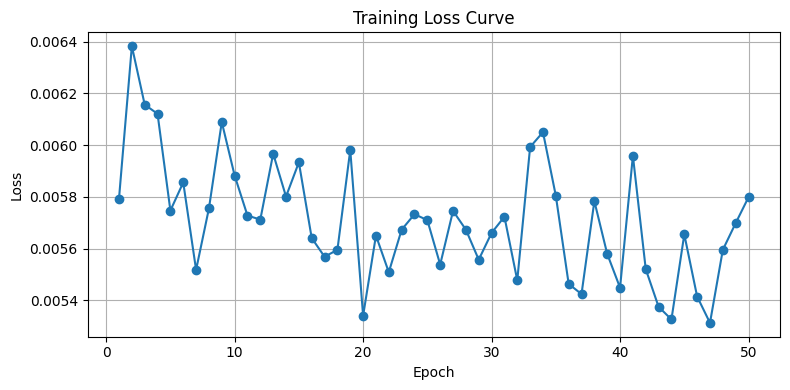

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device: ", device, f"({torch.cuda.get_device_name(device)})" if torch.cuda.is_available() else "")

model = CLIP(emb_dim, vit_width, img_size, patch_size, n_channels, vit_layers, vit_heads, vocab_size, text_width, max_seq_length, text_heads, text_layers).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)

best_loss = np.inf
train_losses = []
for epoch in range(epochs):
  for i, data in enumerate(train_loader, 0):
    img, cap, mask = data["image"].to(device), data["caption"].to(device), data["mask"].to(device)
    loss = model(img, cap, mask)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss = loss.item()

  avg_loss = epoch_loss/len(train_loader)
  train_losses.append(avg_loss)
  print(f"Epoch [{epoch+1}/{epochs}], Batch Loss: {loss.item():.3f}, Average Loss: {avg_loss:.3f}")

  # Save the model if it performed better than the previous one.
  if loss.item() <= best_loss:
    best_loss = loss.item()
    torch.save(model.state_dict(), "clip.pt")
    print("Model Saved")

# Plot Training Time Curve
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

# LOAD THE BEST MODEL

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

model = CLIP(emb_dim, vit_width, img_size, patch_size, n_channels, vit_layers, vit_heads, vocab_size, text_width, max_seq_length, text_heads, text_layers).to(device)
model.load_state_dict(torch.load("clip.pt", map_location=device)) # Load the BEST model

# Getting dataset captions to compare images to
# Tokenize every caption, takes token ids, and stacks them into one tensor
text = torch.stack([tokenizer(x)[0] for x in test_set.captions.values()]).to(device)
# Creating attention masks.
mask = torch.stack([tokenizer(x)[1] for x in test_set.captions.values()])
# Expanding masks for attention.
mask = mask.repeat(1, len(mask[0])).reshape(len(mask), len(mask[0]), len(mask[0])).to(device)

all_preds, all_labels = [], []
with torch.no_grad(): # Disable gradient computation.
  for data in test_loader: # Loop through test data
    images, labels = data["image"].to(device), data["caption"].to(device) # Move data to device.
    image_features = model.image_encoder(images) # Encode images.
    text_features = model.text_encoder(text, mask=mask) # Encode texts.

    # Normalize Embeddings (L2 Normalization).
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Compute Similarity Matrix using DOT PRODUCT.
    similarity = (100.0*image_features @ text_features.T).softmax(dim=-1)

    # Get Predicted Caption
    _, indices = torch.max(similarity, 1)

    # Convert predictions to tokens.
    pred = torch.stack([tokenizer(test_set.captions[int(i)])[0] for i in indices]).to(device)

    # Store results.
    all_preds.extend(indices.cpu().tolist())
    label_indices = torch.stack([
        torch.max((labels[j].unsqueeze(0)==text).all(dim=1).float(), dim=0).indices
        for j in range(len(labels))
    ]).cpu().tolist()
    all_labels.extend(label_indices)


# Metrics
accuracy  = 100 * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
precision = 100 * precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall    = 100 * recall_score   (all_labels, all_preds, average="macro", zero_division=0)
f1        = 100 * f1_score       (all_labels, all_preds, average="macro", zero_division=0)

print(f"Accuracy  : {accuracy:.1f}%")
print(f"Precision : {precision:.1f}%")
print(f"Recall    : {recall:.1f}%")
print(f"F1 Score  : {f1:.1f}%")

Accuracy  : 86.0%
Precision : 86.4%
Recall    : 86.0%
F1 Score  : 86.1%


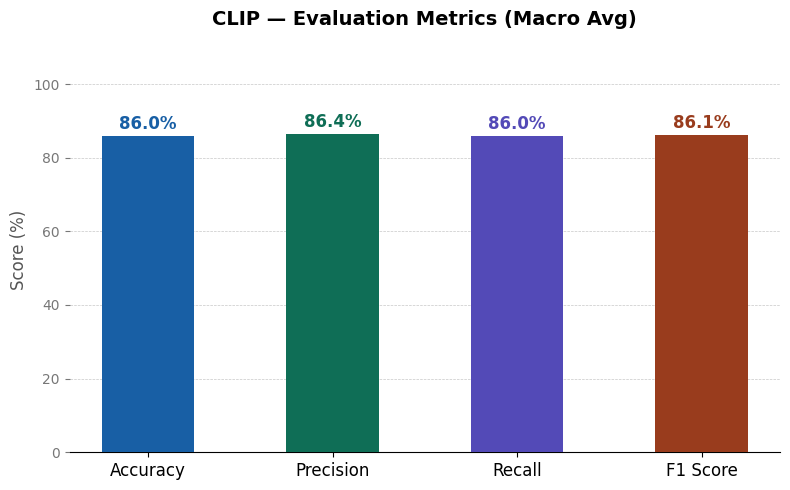

In [49]:
import matplotlib.pyplot as plt
import numpy as np

metrics = {
    "Accuracy":  100 * correct // total,
    "Precision": precision,
    "Recall":    recall,
    "F1 Score":  f1
}

labels = list(metrics.keys())
values = list(metrics.values())
colors = ["#185FA5", "#0F6E56", "#534AB7", "#993C1D"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, values, color=colors, width=0.5, zorder=3)

# Value labels on top of each bar
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold", color=bar.get_facecolor()
    )

ax.set_ylim(0, 110)
ax.set_ylabel("Score (%)", fontsize=12, color="#555")
ax.set_title("CLIP — Evaluation Metrics (Macro Avg)", fontsize=14, fontweight="bold", pad=16)

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, alpha=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=10, colors="#777")

plt.tight_layout()
plt.savefig("eval_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

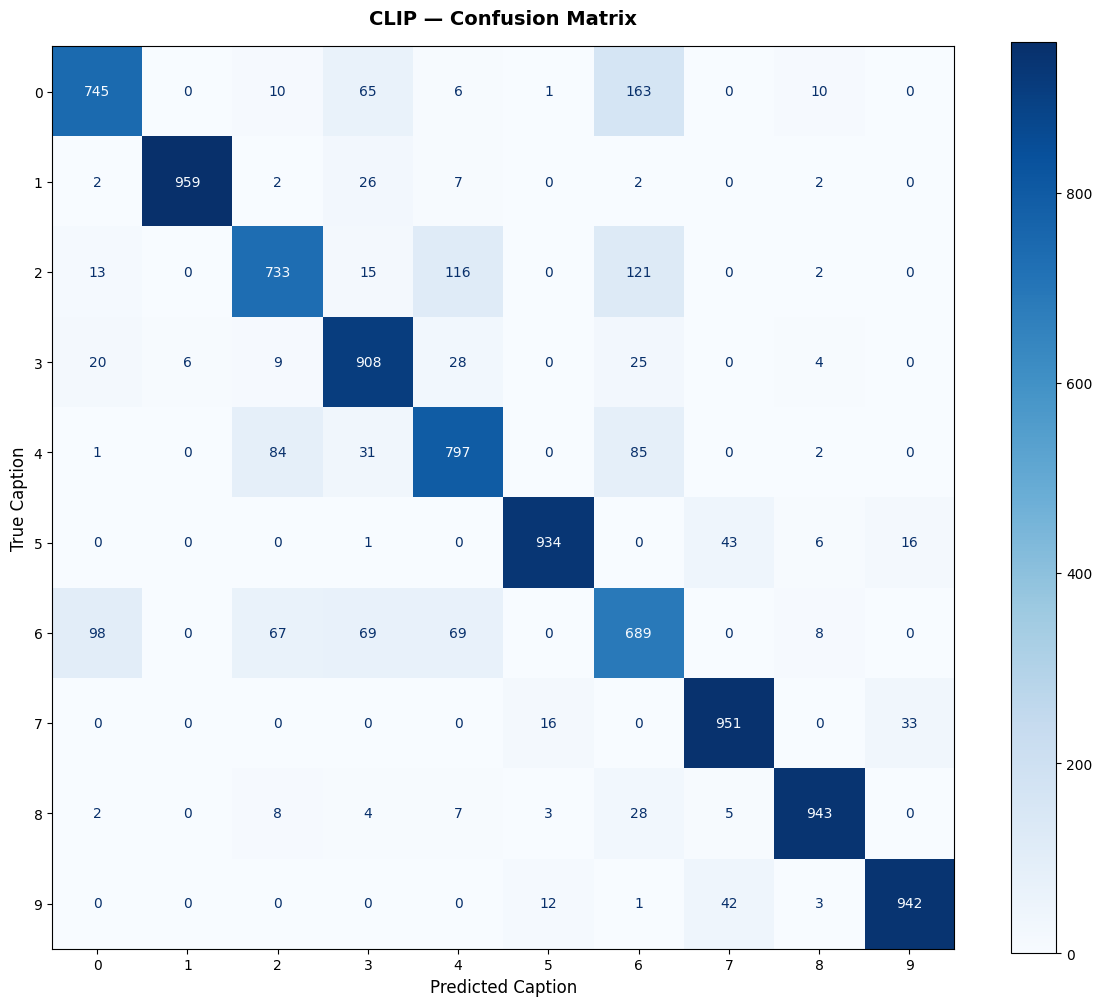

In [50]:
# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    ax=ax,
    colorbar=True,
    cmap="Blues",
)

ax.set_title("CLIP — Confusion Matrix", fontsize=14, fontweight="bold", pad=16)
ax.set_xlabel("Predicted Caption", fontsize=12)
ax.set_ylabel("True Caption", fontsize=12)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# TESTING

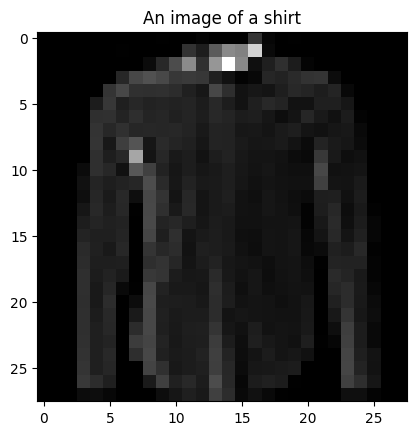


Top predictions:

     t-shirt/top: 99.91%
      ankle boot: 0.09%
           shirt: 0.00%
            coat: 0.00%
        pullover: 0.00%


In [51]:
model = CLIP(emb_dim, vit_width, img_size, patch_size, n_channels, vit_layers, vit_heads, vocab_size, text_width, max_seq_length, text_heads, text_layers).to(device)
model.load_state_dict(torch.load("clip.pt", map_location=device))

class_names =["t-shirt/top","trousers","pullover","dress","coat","sandal","shirt","sneaker","bag","ankle boot"]

text = torch.stack([tokenizer(x)[0] for x in class_names]).to(device)
mask = torch.stack([tokenizer(x)[1] for x in class_names])
mask = mask.repeat(1,len(mask[0])).reshape(len(mask),len(mask[0]),len(mask[0])).to(device)

idx = 198

img = test_set[idx]["image"][None,:]
plt.imshow(img[0].permute(1, 2, 0)  ,cmap="gray")
plt.title(tokenizer(test_set[idx]["caption"], encode=False, mask=test_set[idx]["mask"][0])[0])
plt.show()
img = img.to(device)
with torch.no_grad():
  image_features = model.image_encoder(img)
  text_features = model.text_encoder(text, mask=mask)


image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
values, indices = similarity[0].topk(5)

# Print the result
print("\nTop predictions:\n")
for value, index in zip(values, indices):
    print(f"{class_names[int(index)]:>16s}: {100 * value.item():.2f}%")